Objective

Transform the IndiGo route network into a business dataset by generating realistic airline KPIs:



*   Passenger Demand
*   Aircraft Capacity




*   Load Factor
*   Average Ticket Price





*  Revenue
*  Fuel Cost




*   Operating Cost
*   Profit




*   Profit Margin




# IndiGo Route Profitability Engine


Goal:
Build route-level profitability metrics for IndiGo routes and identify the most profitable and least profitable routes.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

pd.set_option("display.max_columns", None)

In [ ]:
indigo = pd.read_csv(
    "indigo_route_master.csv"
)

indigo.head()

,Airline,Airline_ID,Source_Airport,Source_Airport_ID,Destination_Airport,Destination_Airport_ID,Codeshare,Stops,Equipment,Source_Airport_Name,Source_City,Source_Country,Source_Latitude,Source_Longitude,Destination_Airport_Name,Destination_City,Destination_Country,Destination_Latitude,Destination_Longitude,Route,Route_Type
0,6E,2850.0,AMD,2994.0,BLR,3131.0,NaN,0,320,Sardar Vallabhbhai Patel International Airport,Ahmedabad,India,23.0772,72.634697,Kempegowda International Airport,Bangalore,India,13.197900,77.706299,Sardar Vallabhbhai Patel International Airport...,Domestic
1,6E,2850.0,AMD,2994.0,BOM,2997.0,NaN,0,320,Sardar Vallabhbhai Patel International Airport,Ahmedabad,India,23.0772,72.634697,Chhatrapati Shivaji International Airport,Mumbai,India,19.088699,72.867897,Sardar Vallabhbhai Patel International Airport...,Domestic
2,6E,2850.0,AMD,2994.0,CCU,3043.0,NaN,0,320,Sardar Vallabhbhai Patel International Airport,Ahmedabad,India,23.0772,72.634697,Netaji Subhash Chandra Bose International Airport,Kolkata,India,22.654699,88.446701,Sardar Vallabhbhai Patel International Airport...,Domestic
3,6E,2850.0,AMD,2994.0,DEL,3093.0,NaN,0,320,Sardar Vallabhbhai Patel International Airport,Ahmedabad,India,23.0772,72.634697,Indira Gandhi International Airport,Delhi,India,28.566500,77.103104,Sardar Vallabhbhai Patel International Airport...,Domestic
4,6E,2850.0,AMD,2994.0,GOI,3007.0,NaN,0,320,Sardar Vallabhbhai Patel International Airport,Ahmedabad,India,23.0772,72.634697,Dabolim Airport,Goa,India,15.380800,73.831398,Sardar Vallabhbhai Patel International Airport...,Domestic


In [ ]:
print(indigo.shape)

(199, 21)


In [ ]:
indigo["Aircraft_Capacity"] = np.random.randint(
    180,
    230,
    size=len(indigo)
)

In [ ]:
indigo["Load_Factor"] = np.random.uniform(
    0.65,
    0.95,
    len(indigo)
)

In [ ]:
indigo["Passengers"] = (
    indigo["Aircraft_Capacity"]
    *
    indigo["Load_Factor"]
).astype(int)

In [ ]:
indigo["Avg_Ticket_Price"] = np.where(
    indigo["Route_Type"]=="Domestic",
    np.random.randint(
        3500,
        9000,
        len(indigo)
    ),
    np.random.randint(
        9000,
        25000,
        len(indigo)
    )
)

In [ ]:
indigo["Revenue"] = (
    indigo["Passengers"]
    *
    indigo["Avg_Ticket_Price"]
    *
    indigo["Flights_Per_Year"]
)

In [ ]:
indigo["Flights_Per_Day"] = np.random.randint(
    1,
    8,
    len(indigo)
)

In [ ]:
indigo["Flights_Per_Year"] = (
    indigo["Flights_Per_Day"] * 365
)

In [ ]:
indigo["Fuel_Cost"] = np.where(
    indigo["Route_Type"]=="Domestic",
    np.random.randint(
        200000,
        800000,
        len(indigo)
    ),
    np.random.randint(
        700000,
        2500000,
        len(indigo)
    )
)

In [ ]:
indigo["Airport_Charges"] = np.random.randint(
    50000,
    250000,
    len(indigo)
)

In [ ]:
indigo["Crew_Cost"] = np.random.randint(
    30000,
    120000,
    len(indigo)
)

In [ ]:
indigo["Maintenance_Cost"] = np.random.randint(
    25000,
    100000,
    len(indigo)
)

In [ ]:
indigo["Operating_Cost"] = (
    indigo["Fuel_Cost"]
    +
    indigo["Airport_Charges"]
    +
    indigo["Crew_Cost"]
    +
    indigo["Maintenance_Cost"]
) * indigo["Flights_Per_Year"]

In [ ]:
indigo["Profit"] = (
    indigo["Revenue"]
    -
    indigo["Operating_Cost"]
)

In [ ]:
indigo["Profit_Margin"] = (
    indigo["Profit"]
    /
    indigo["Revenue"]
) * 100

In [ ]:
indigo[
    [
        "Route",
        "Passengers",
        "Revenue",
        "Operating_Cost",
        "Profit",
        "Profit_Margin"
    ]
].head()

,Route,Passengers,Revenue,Operating_Cost,Profit,Profit_Margin
0,Sardar Vallabhbhai Patel International Airport...,157,2357298480,1397970075,959328405,40.696094
1,Sardar Vallabhbhai Patel International Airport...,145,1597276500,367699540,1229576960,76.979594
2,Sardar Vallabhbhai Patel International Airport...,138,1672334370,1222250680,450083690,26.913499
3,Sardar Vallabhbhai Patel International Airport...,181,2295890880,1517787530,778103350,33.891129
4,Sardar Vallabhbhai Patel International Airport...,144,1739210400,2710696590,-971486190,-55.857888


In [ ]:
total_revenue = indigo["Revenue"].sum()
total_profit = indigo["Profit"].sum()

company_margin = (
    total_profit / total_revenue
) * 100

print(
    "Total Revenue:",
    round(total_revenue/1e9,2),
    "Billion"
)

print(
    "Total Profit:",
    round(total_profit/1e9,2),
    "Billion"
)

print(
    "Company Margin:",
    round(company_margin,2),
    "%"
)

Total Revenue: 341.81 Billion
Total Profit: 88.24 Billion
Company Margin: 25.82 %


In [ ]:
print(
    (indigo["Profit"] < 0).sum(),
    "loss-making routes"
)

print(
    (indigo["Profit"] > 0).sum(),
    "profitable routes"
)

74 loss-making routes
125 profitable routes


In [ ]:
print("Total IndiGo Routes:", len(indigo))

Total IndiGo Routes: 199


In [ ]:
top_routes = (
    indigo
    .sort_values(
        "Profit",
        ascending=False
    )
    .head(20)
)

top_routes[
    ["Route","Profit"]
]

,Route,Profit
109,Dubai International Airport → Chhatrapati Shiv...,10013481905
91,Indira Gandhi International Airport → Dubai In...,4359367645
110,Dubai International Airport → Cochin Internati...,4112516320
42,Chhatrapati Shivaji International Airport → Da...,3614000050
16,Suvarnabhumi Airport → Indira Gandhi Internati...,3430959850
49,Chhatrapati Shivaji International Airport → Mu...,2993735475
160,Chennai International Airport → Indira Gandhi ...,2937389695
161,Chennai International Airport → Dubai Internat...,2857126560
78,Cochin International Airport → Dubai Internati...,2672986980
126,Devi Ahilyabai Holkar Airport → Indira Gandhi ...,2555374855


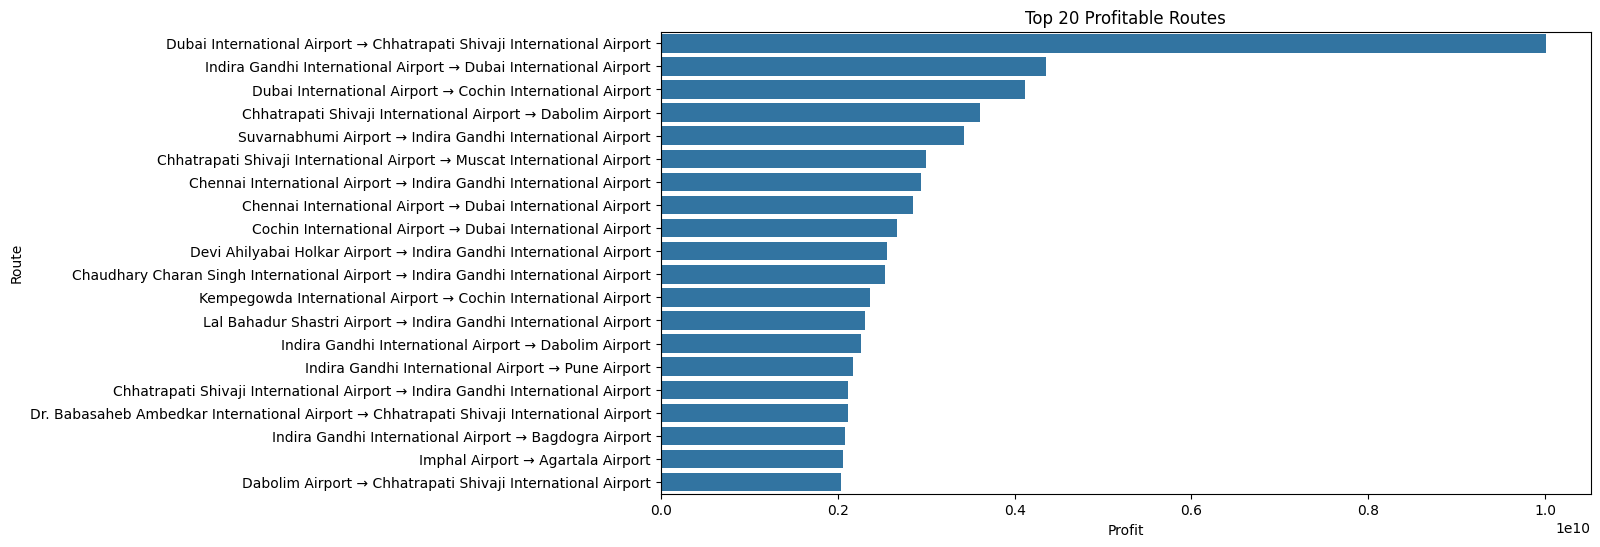

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_routes,
    x="Profit",
    y="Route"
)

plt.title(
    "Top 20 Profitable Routes"
)

plt.show()

In [ ]:
bottom_routes = (
    indigo
    .sort_values(
        "Profit"
    )
    .head(20)
)

bottom_routes[
    ["Route","Profit"]
]

,Route,Profit
193,Trivandrum International Airport → Dubai Inter...,-3810609855
149,Tribhuvan International Airport → Indira Gandh...,-3488462680
113,Dubai International Airport → Trivandrum Inter...,-2126947710
26,Kempegowda International Airport → Chaudhary C...,-2006985715
192,Trivandrum International Airport → Cochin Inte...,-1883768650
82,Indira Gandhi International Airport → Biju Pat...,-1500288335
101,Indira Gandhi International Airport → Dr. Baba...,-1414893665
97,Indira Gandhi International Airport → Birsa Mu...,-1376710650
182,Pune Airport → Dr. Babasaheb Ambedkar Internat...,-1368539760
129,Imphal Airport → Netaji Subhash Chandra Bose I...,-1345615935


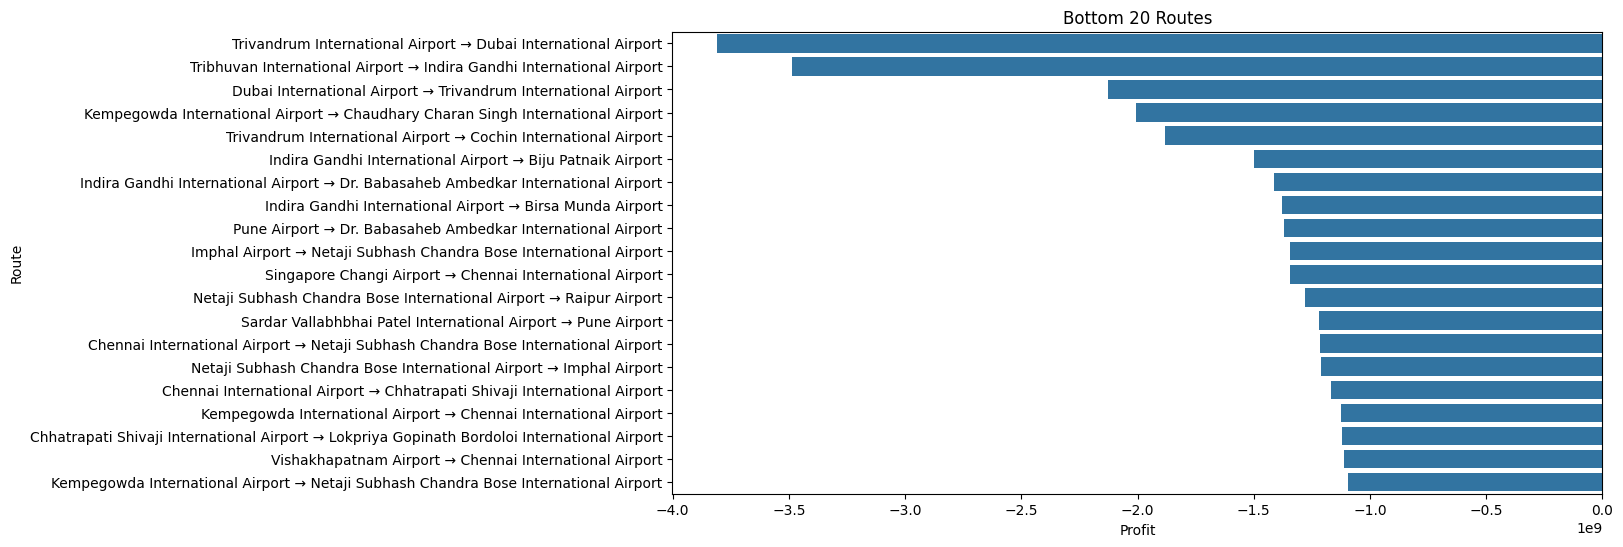

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=bottom_routes,
    x="Profit",
    y="Route"
)

plt.title(
    "Bottom 20 Routes"
)

plt.show()

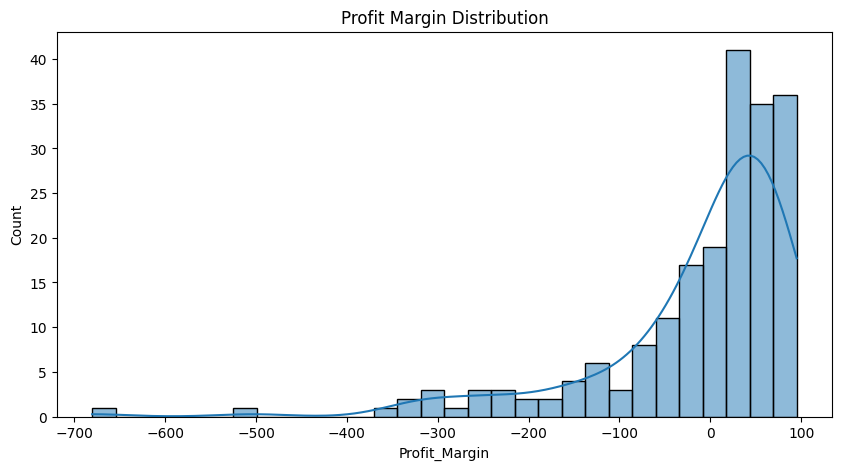

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    indigo["Profit_Margin"],
    bins=30,
    kde=True
)

plt.title(
    "Profit Margin Distribution"
)

plt.show()

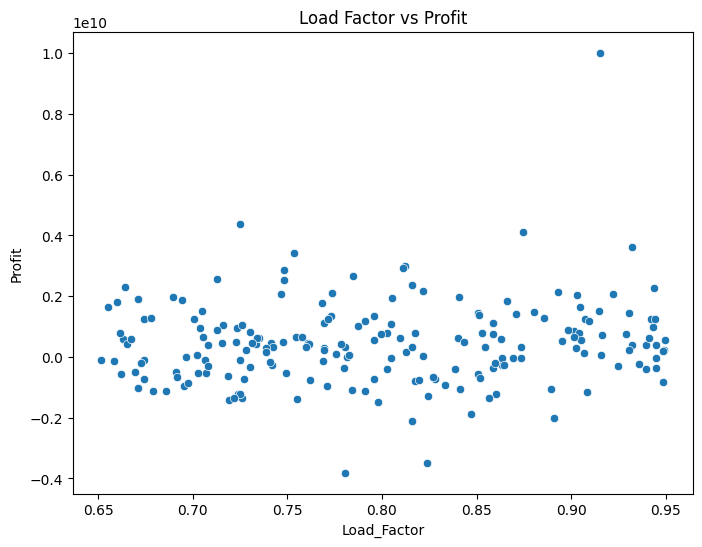

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=indigo,
    x="Load_Factor",
    y="Profit"
)

plt.title(
    "Load Factor vs Profit"
)

plt.show()

In [ ]:
route_profit = (
    indigo
    .groupby("Route_Type")
    ["Profit"]
    .sum()
)

route_profit

,Profit
Route_Type,
Domestic,65083187595
International,23156149325


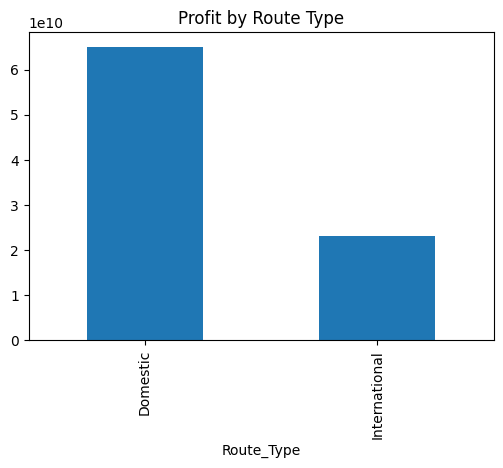

In [ ]:
route_profit.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title(
    "Profit by Route Type"
)

plt.show()

In [ ]:
airport_profit = (
    indigo
    .groupby("Source_Airport_Name")
    ["Profit"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(15)
)

airport_profit

,Profit
Source_Airport_Name,
Indira Gandhi International Airport,19062917780
Chhatrapati Shivaji International Airport,18682610775
Dubai International Airport,11203724275
Chennai International Airport,7046954625
Devi Ahilyabai Holkar Airport,6477661205
Suvarnabhumi Airport,5238791710
Netaji Subhash Chandra Bose International Airport,4156203170
Dabolim Airport,3790238475
Dr. Babasaheb Ambedkar International Airport,3538251600


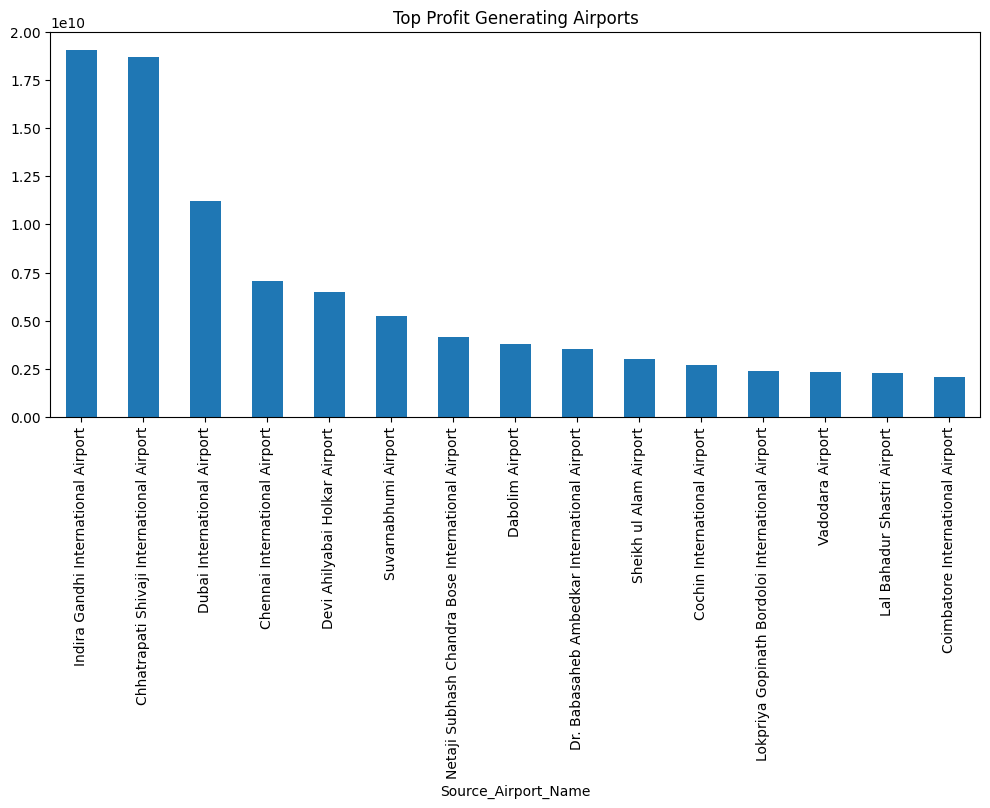

In [ ]:
airport_profit.plot(
    kind="bar",
    figsize=(12,5)
)

plt.title(
    "Top Profit Generating Airports"
)

plt.show()

In [ ]:
conditions = [
    indigo["Profit_Margin"] > 40,
    indigo["Profit_Margin"] > 20,
    indigo["Profit_Margin"] <= 20
]

choices = [
    "High Profit",
    "Medium Profit",
    "Low Profit"
]

indigo["Profit_Category"] = np.select(
    conditions,
    choices,
    default="Low Profit"
)

In [ ]:
indigo["Profit_Category"]\
.value_counts()

,count
Profit_Category,
Low Profit,88
High Profit,74
Medium Profit,37


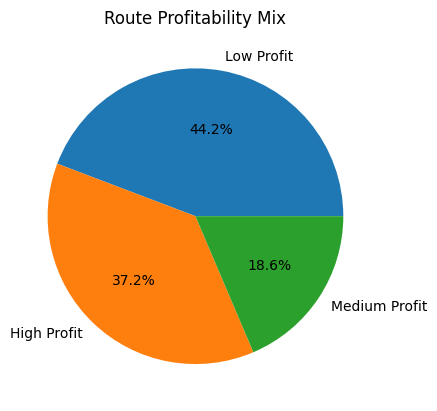

In [ ]:
indigo["Profit_Category"]\
.value_counts()\
.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title(
    "Route Profitability Mix"
)

plt.show()

In [ ]:
indigo.to_csv(
    "indigo_profitability.csv",
    index=False
)

print(
    "Profitability Dataset Saved"
)

Profitability Dataset Saved


In [ ]:
print("="*60)

print("INDIGO ROUTE PROFITABILITY REPORT")

print("="*60)

print(
    "Routes Analysed:",
    len(indigo)
)

print(
    "Revenue:",
    round(
        indigo["Revenue"].sum()/1e9,
        2
    ),
    "Billion"
)

print(
    "Profit:",
    round(
        indigo["Profit"].sum()/1e9,
        2
    ),
    "Billion"
)

print(
    "Average Profit Margin:",
    round(
        indigo["Profit_Margin"].mean(),
        2
    ),
    "%"
)

print()

print(
    "Most Profitable Route:"
)

print(
    top_routes.iloc[0]["Route"]
)

print()

print(
    "Least Profitable Route:"
)

print(
    bottom_routes.iloc[0]["Route"]
)

print("="*60)

INDIGO ROUTE PROFITABILITY REPORT
Routes Analysed: 199
Revenue: 341.81 Billion
Profit: 88.24 Billion
Average Profit Margin: -12.24 %

Most Profitable Route:
Dubai International Airport → Chhatrapati Shivaji International Airport

Least Profitable Route:
Trivandrum International Airport → Dubai International Airport
